### Context
This dataset is used for Face Mask Detection Classification with images. The dataset consists of almost 12K images which are almost 328.92MB in size.

### Acknowledgments
All the images with the face mask (~6K) are scrapped from google search and all the images without the face mask are preprocessed from the CelebFace dataset created by Jessica Li (https://www.kaggle.com/jessicali9530).

## Imports

In [20]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

## Configuration

In [21]:
DATA_DIR = "dataset"
IMG_SIZE = 224

## Load Dataset

In [22]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("dataset/train", transform=transform)

print("Classes:", train_dataset.classes)

Classes: ['WithMask', 'WithoutMask']


## Class Count

In [23]:
labels = [label for _, label in train_dataset]

counts = Counter(labels)

class_names = train_dataset.classes

for i, cls in enumerate(class_names):
    print(f"{cls}: {counts[i]} images")

print("\nTotal images:", len(train_dataset))

WithMask: 5000 images
WithoutMask: 5000 images

Total images: 10000


## Class Distribution Plot

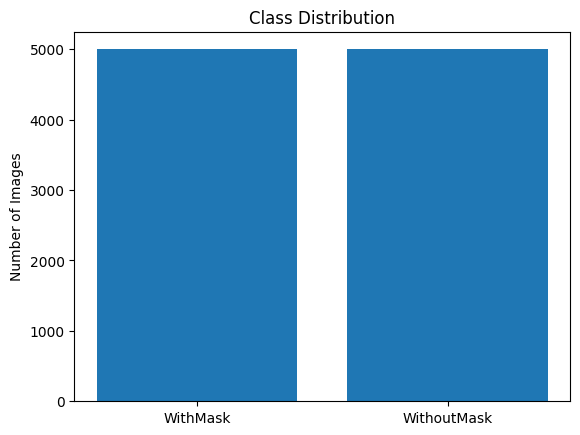

In [24]:
values = [counts[i] for i in range(len(class_names))]

plt.bar(class_names, values)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

## Random Image Samples

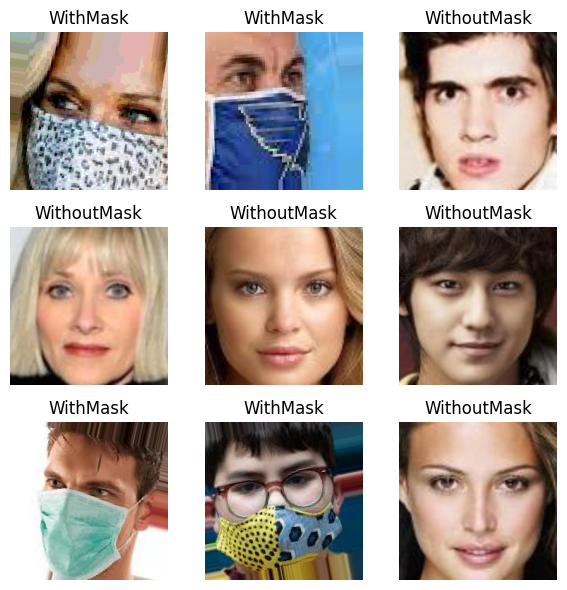

In [29]:
import random

def show_random_images(dataset, n=9):
    plt.figure(figsize=(6,6))

    for i in range(n):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]

        plt.subplot(3,3,i+1)
        plt.imshow(img.permute(1,2,0))
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(train_dataset)

## Brightness Distribution

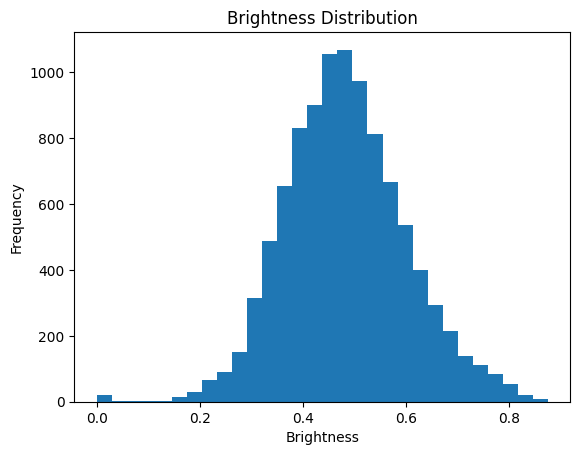

In [26]:
brightness_values = []

for img, _ in train_dataset:
    brightness_values.append(img.mean().item())

plt.hist(brightness_values, bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

## STD Comparison Between Classes (Catastrophic Problem Detection)

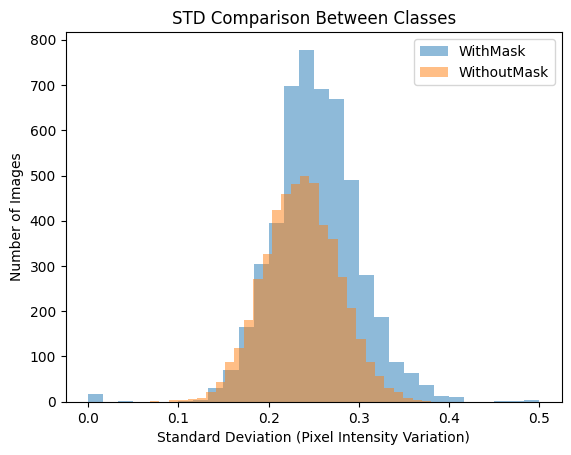

In [28]:
mask_std = []
no_mask_std = []

for img, label in train_dataset:
    if label == 0:  # WithMask
        mask_std.append(img.std().item())
    else:
        no_mask_std.append(img.std().item())

import matplotlib.pyplot as plt

plt.hist(mask_std, bins=30, alpha=0.5, label="WithMask")
plt.hist(no_mask_std, bins=30, alpha=0.5, label="WithoutMask")
plt.xlabel("Standard Deviation (Pixel Intensity Variation)")
plt.ylabel("Number of Images")
plt.title("STD Comparison Between Classes")
plt.legend()
plt.title("STD Comparison Between Classes")
plt.show()